# Statistická práce - NBA

In [5]:
import kagglehub

# Download latest version
nba_dataset1 = kagglehub.dataset_download(
    "eoinamoore/historical-nba-data-and-player-box-scores",
    output_dir=".data/NBA Dataset: Box Scores and Stats (1947 - Today)"
)
nba_dataset2 = kagglehub.dataset_download(
    "wyattowalsh/basketball",
    output_dir=".data/NBA_Database"
)

print("Path to dataset files:", nba_dataset1)
print("Path to dataset files:", nba_dataset2)

Path to dataset files: .data/NBA Dataset: Box Scores and Stats (1947 - Today)
Path to dataset files: .data/NBA_Database


## Odpočinek mezi zápasy

In [6]:
from collections import defaultdict

import pandas

class Team:
    def __init__(self, team_id, team_name):
        self.team_id = team_id
        self.team_name = team_name

    def __str__(self):
        return f"Team ID: {self.team_id}, Team Name: {self.team_name}"

games = pandas.read_csv(".data/NBA_Database/csv/game.csv")
teams_details = pandas.read_csv(".data/NBA_Database/csv/team.csv")

teams = [Team(team_id, team_name) for team_id, team_name in zip(teams_details["id"], teams_details["full_name"])]

print(*teams)

class Counter:
    def __init__(self):
        self.count = 0
        self.wins = 0

    def increment(self):
        self.count += 1

    def win(self):
        self.wins += 1
        self.increment()
    
    def lose(self):
        self.increment()

time_to_win = defaultdict(Counter)

for team in teams:
    games_iter = list(games[(games["team_id_home"] == team.team_id) | (games["team_id_away"] == team.team_id)].sort_values(by="game_date").iterrows())

    for (_, pref), (_, curr) in zip(games_iter, games_iter[1:]):
        date_diff = pandas.to_datetime(curr["game_date"]) - pandas.to_datetime(pref["game_date"])

        if (curr["team_id_home"] == team.team_id and curr["wl_home"] == "W") or (curr["team_id_away"] == team.team_id and curr["wl_away"] == "W"):
            time_to_win[date_diff.days].win()
        else:
            time_to_win[date_diff.days].lose()

    

for days, counter in time_to_win.items():
    print(f"Days: {days}, Total Games: {counter.count}, Wins: {counter.wins}")





Team ID: 1610612737, Team Name: Atlanta Hawks Team ID: 1610612738, Team Name: Boston Celtics Team ID: 1610612739, Team Name: Cleveland Cavaliers Team ID: 1610612740, Team Name: New Orleans Pelicans Team ID: 1610612741, Team Name: Chicago Bulls Team ID: 1610612742, Team Name: Dallas Mavericks Team ID: 1610612743, Team Name: Denver Nuggets Team ID: 1610612744, Team Name: Golden State Warriors Team ID: 1610612745, Team Name: Houston Rockets Team ID: 1610612746, Team Name: Los Angeles Clippers Team ID: 1610612747, Team Name: Los Angeles Lakers Team ID: 1610612748, Team Name: Miami Heat Team ID: 1610612749, Team Name: Milwaukee Bucks Team ID: 1610612750, Team Name: Minnesota Timberwolves Team ID: 1610612751, Team Name: Brooklyn Nets Team ID: 1610612752, Team Name: New York Knicks Team ID: 1610612753, Team Name: Orlando Magic Team ID: 1610612754, Team Name: Indiana Pacers Team ID: 1610612755, Team Name: Philadelphia 76ers Team ID: 1610612756, Team Name: Phoenix Suns Team ID: 1610612757, Team

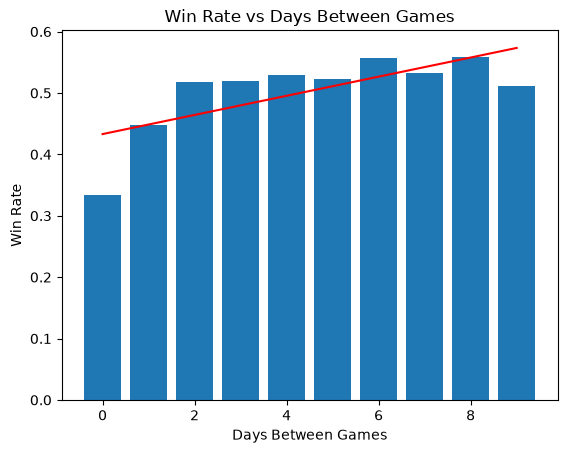

Slope: 0.015589364960987442


In [7]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

fig, ax = plt.subplots()
days = list(key for key in time_to_win.keys() if key < 10)
win_rate = [time_to_win[day].wins / time_to_win[day].count if time_to_win[day].count > 0 else 0 for day in days]

x_line = np.linspace(min(days), max(days), 100)
result = linregress(days, win_rate)

y_line = result.slope * x_line + result.intercept

ax.plot(
    x_line,
    y_line,
    label=f"y = {result.slope:.2f}x + {result.intercept:.2f}",
    color="red"
)

ax.bar(days, win_rate)
ax.set_xlabel("Days Between Games")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate vs Days Between Games")
plt.show()

#print(f"Slope: {result.slope}, Intercept: {result.intercept}, R-value: {result.rvalue}, P-value: {result.pvalue}, Std Err: {result.stderr}")
print(f"Slope: {result.slope}")

# Nejlepší hráč v týmu

In [8]:
games_combined = games.merge(pandas.read_csv(".data/NBA Dataset: Box Scores and Stats (1947 - Today)/Games.csv", low_memory=False), left_on="game_id", right_on="gameId", how="inner")

player_stats = pandas.read_csv(".data/NBA Dataset: Box Scores and Stats (1947 - Today)/PlayerStatisticsExtended.csv", low_memory=False)